# Emotion Detection - 01: EDA

Recognise the facial expression in a photo. Dataset: **FER2013** via HuggingFace `AutumnQiu/fer2013`, 7 emotions (angry, disgust, fear, happy, neutral, sad, surprise), originally 48x48 grayscale faces. A committed 64x64 sample sits under `data/sample/<emotion>/`.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
imgs, labels, classes = utils.load_sample()
print('classes:', len(classes)); print(classes)
print('total images:', len(imgs))

classes: 7
['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
total images: 1750


## 1. Class balance

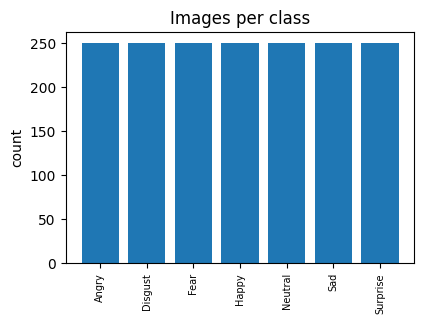

Angry                  250
Disgust                250
Fear                   250
Happy                  250
Neutral                250
Sad                    250
Surprise               250


In [2]:
import collections
cnt = collections.Counter(labels)
plt.figure(figsize=(min(14,1+len(classes)*0.5),3)); plt.bar(range(len(classes)), [cnt[c] for c in classes])
plt.xticks(range(len(classes)), classes, rotation=90, fontsize=7); plt.ylabel('count'); plt.title('Images per class'); plt.show()
for k in classes: print('%-22s %d' % (k, cnt[k]))

## 2. One sample per class

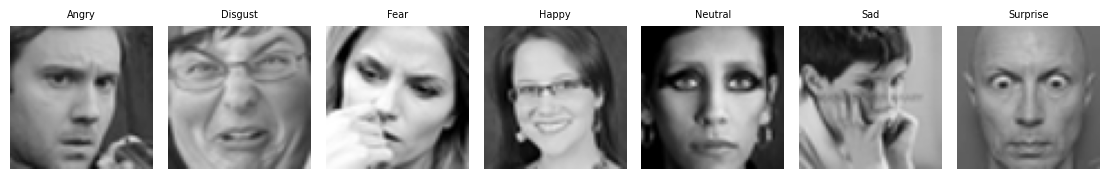

In [3]:
import math
n=len(classes); cols=min(n,10); rows=math.ceil(n/cols)
fig, ax = plt.subplots(rows, cols, figsize=(1.6*cols, 1.8*rows)); ax=np.atleast_2d(ax)
seen={}
for im,l in zip(imgs,labels):
    if l in seen: continue
    seen[l]=im
for i,cl in enumerate(classes):
    a=ax[i//cols][i%cols]; a.imshow(seen[cl]); a.set_title(cl, fontsize=7); a.axis('off')
for j in range(n, rows*cols): ax[j//cols][j%cols].axis('off')
plt.tight_layout(); plt.show()

### Findings
Seven emotion classes, imbalanced (happy is common, disgust is rare). Faces are tiny, grayscale, and expressions are subtle. This is a genuinely hard task even for humans on 48x48 crops.